# Small Inversions (NAIBR)
Here, we visualize the inversions that were identified for the `small` treatment across the range of depths.

In [45]:
library(ggplot2)
library(ggpattern)
library(dplyr)
library(ggpubr)
.size <- "small"

These are the setup functions that process that data.

In [46]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    truthfile <- paste0("../simulated_variants/setup_inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("../simulated_data/called_sv/naibr", size_treatment, .depth, "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("../simulated_data/called_sv/naibr", size_treatment, .depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"
    true_inversions$size <- size_treatment


    sample_inversions <- read.table(samplesfile, header = T)[,c(1:3,5)]
    names(sample_inversions) <- c("sample", "contig", "position_start", "position_end")
    if( nrow(sample_inversions) > 0){
        sample_inversions$size <- size_treatment
    }

    pooled_inversions <- read.table(poolfile, header = T)[,c(1:3,5)]
    names(pooled_inversions) <- c("sample", "contig", "position_start", "position_end")
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- "pooled"
        pooled_inversions$size <- size_treatment
    }
    outdf <- rbind(true_inversions, sample_inversions, pooled_inversions)
    outdf$depth <- depth
    return(outdf)
}

read_all_data <- function(size_treatment){
    depth <- 0.5
    .data <- read_data(size_treatment, depth)    
    for(i in c(2,5,10,20)){
        .data <- rbind(.data, read_data(size_treatment, i))    
    }
    return(.data[,c(4,1,2,3,5,6)])
}

In [47]:
SV <- read_all_data(.size)
samplesSV <- SV[SV$sample != "simulated_inversions",]
head(samplesSV)

sample,contig,position_start,position_end,size,depth
<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>


Read in the sample and pool simulation inventory

In [48]:
inventory <- rbind(
    filter(read.table("../inversion_simulations.inventory", header = T), size == .size),
    filter(read.table("../inversion_simulations.pool.inventory", header = T), size == .size)
)
inventory <- rename(inventory, "simulated" = "present", "zygosity" = "state")

# set a default to false negatives, to be updated to true positives when conditions are met
inventory$assessment <- ifelse(inventory$simulated, "false negative", "true negative")
inventory$sample <- gsub("pool", "pooled", inventory$sample)
head(inventory)

,sample,size,contig,inversion,simulated,zygosity,assessment
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<chr>
1,sample_01,small,2R,1,TRUE,het,false negative
2,sample_01,small,2R,2,TRUE,het,false negative
3,sample_01,small,2R,3,TRUE,het,false negative
4,sample_01,small,2R,4,TRUE,het,false negative
5,sample_01,small,2R,5,TRUE,het,false negative
6,sample_02,small,2R,1,TRUE,het,false negative


In [49]:
# add depths to performance
# arrange() is for sanity-checking
performance <- inventory
performance$depth <- 0.5
for(i in c(2, 5, 10, 20)){
    inventory$depth <- i
    performance <- rbind(performance, inventory)
}
performance <- arrange(performance, sample, contig, inversion)
head(performance)

,sample,size,contig,inversion,simulated,zygosity,assessment,depth
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<chr>,<dbl>
1,pooled,small,2L,1,TRUE,hom,false negative,0.5
2,pooled,small,2L,1,TRUE,hom,false negative,2.0
3,pooled,small,2L,1,TRUE,hom,false negative,5.0
4,pooled,small,2L,1,TRUE,hom,false negative,10.0
5,pooled,small,2L,1,TRUE,hom,false negative,20.0
6,pooled,small,2L,2,TRUE,hom,false negative,0.5


In [50]:
## read in truth data to transfer inversion breakpoints
x <- read_data(.size, 0.5)
for(i in c(2,5,10,20)){
    x <- rbind(x, read_data(.size, i))
}
x <- arrange(x, sample, contig, position_start, depth)
head(x)

,contig,position_start,position_end,sample,size,depth
,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>
1,2L,3193196,3214221,simulated_inversions,small,0.5
2,2L,3193196,3214221,simulated_inversions,small,2.0
3,2L,3193196,3214221,simulated_inversions,small,5.0
4,2L,3193196,3214221,simulated_inversions,small,10.0
5,2L,3193196,3214221,simulated_inversions,small,20.0
6,2L,3940211,3944863,simulated_inversions,small,0.5


In [51]:
truth <- group_by(x[x$sample == "simulated_inversions",], contig, depth) %>% mutate(inversion = 1:n()) %>% ungroup()
head(truth)

contig,position_start,position_end,sample,size,depth,inversion
<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>,<int>
2L,3193196,3214221,simulated_inversions,small,0.5,1
2L,3193196,3214221,simulated_inversions,small,2.0,1
2L,3193196,3214221,simulated_inversions,small,5.0,1
2L,3193196,3214221,simulated_inversions,small,10.0,1
2L,3193196,3214221,simulated_inversions,small,20.0,1
2L,3940211,3944863,simulated_inversions,small,0.5,2


In [52]:
# merge it all together
performance <- merge(performance,truth[,c(-4,-5)], by = c("contig", "inversion", "depth"))
performance$id <- as.integer(as.factor(performance$position_start))
performance <- arrange(performance, contig, inversion, "sample", depth)[, c(1,2,11,3,4:10)]
head(performance, 15)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<int>,<dbl>
1,2L,1,1,0.5,pooled,small,TRUE,hom,false negative,3193196,3214221
2,2L,1,1,0.5,sample_07,small,TRUE,hom,false negative,3193196,3214221
3,2L,1,1,0.5,sample_05,small,TRUE,hom,false negative,3193196,3214221
4,2L,1,1,0.5,sample_01,small,TRUE,hom,false negative,3193196,3214221
5,2L,1,1,0.5,sample_10,small,TRUE,hom,false negative,3193196,3214221
6,2L,1,1,0.5,sample_03,small,TRUE,hom,false negative,3193196,3214221
7,2L,1,1,0.5,sample_08,small,TRUE,hom,false negative,3193196,3214221
8,2L,1,1,0.5,sample_09,small,TRUE,hom,false negative,3193196,3214221
9,2L,1,1,0.5,sample_06,small,TRUE,hom,false negative,3193196,3214221


### Assess the performance of identified inversions

In [53]:
false_positives <- samplesSV[0,]

for(i in 1:nrow(samplesSV)){
    .row <- samplesSV[i,]
    query <- which(
        performance$sample == .row$sample &
        performance$depth == .row$depth &
        performance$contig == .row$contig &
        performance$position_start - 50 <= .row$position_start &
        performance$position_end + 50 >= .row$position_end
    )
    if(length(query) > 0 && performance$simulated[query]){
        performance$assessment[query] <- "true positive"
    } else {
        performance$assessment[query] <- "false positive"
        false_positives <- rbind(false_positives, .row)
    }
}
head(performance)
head(false_positives)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<int>,<dbl>
1,2L,1,1,0.5,pooled,small,TRUE,hom,false negative,3193196,3214221
2,2L,1,1,0.5,sample_07,small,TRUE,hom,false negative,3193196,3214221
3,2L,1,1,0.5,sample_05,small,TRUE,hom,false negative,3193196,3214221
4,2L,1,1,0.5,sample_01,small,TRUE,hom,false negative,3193196,3214221
5,2L,1,1,0.5,sample_10,small,TRUE,hom,false negative,3193196,3214221
6,2L,1,1,0.5,sample_03,small,TRUE,hom,false negative,3193196,3214221


,sample,contig,position_start,position_end,size,depth
,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>
NA,NA,NA,NA,NA,NA,NA


This is extra formatting we need to do to get it to plot correctly

In [62]:
performance$sample <- gsub("sample_", "", performance$sample)
performance$sample <- gsub("pooled", "11", performance$sample)
performance$sample <- as.integer(performance$sample)

simulated_for_plot <- truth
simulated_for_plot$assessment <- "true positive"
simulated_for_plot$sample <- 0
simulated_for_plot <- simulated_for_plot[simulated_for_plot$depth == 20, -5]
head(simulated_for_plot)

contig,position_start,position_end,sample,depth,inversion,assessment
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<chr>
2L,3193196,3214221,0,20,1,true positive
2L,3940211,3944863,0,20,2,true positive
2L,13024404,13026577,0,20,3,true positive
2L,14845709,14861200,0,20,4,true positive
2L,20107901,20113695,0,20,5,true positive
2R,4328632,4333509,0,20,1,true positive


### Single-Sample Detection
Let's first visualize what detection looked like across the genome. Here, we facet across contigs and show all the depths at once. Since the small inversions are indeed quite small, for visualization purposes, we'll make each of them 100 kb bigger.

In [63]:
plot_inversions <- function(data, groundtruth, size_treatment){
    options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
    .tbl <- filter(data, assessment == "true positive") %>% select(contig, inversion, position_start, position_end, depth, assessment, sample)
    
    rbind(.tbl, groundtruth) %>%

    ggplot(
        aes(
            x = sample,
            ymin = position_start,
            ymax = position_end+100000,
            color = as.factor(depth),
        )
    ) +
        geom_linerange(position = position_dodge(0.7), linewidth = 1.5) +
        coord_flip() +
        scale_color_brewer(name = "sequencing depth", palette = "Set2") +
        scale_x_continuous(breaks = 0:11,limits = c(0, 11)) +
        scale_y_continuous(labels = scales::comma) +
        theme_light() +
        theme(
            panel.grid.major.y = element_blank(),
            legend.position = "top",
            panel.grid.minor.y = element_line(color = "gray80", size = 0.5)
        ) +
        labs(
            title = "Simulated and Called Inversions Across the Genome",
            subtitle = paste0("Size: ", size_treatment),
            y = "genomic position (bp)",
            caption = "sample 0 = groundtruth | sample 11 = pooled"
        ) + 
        facet_grid(cols = vars(contig))
}

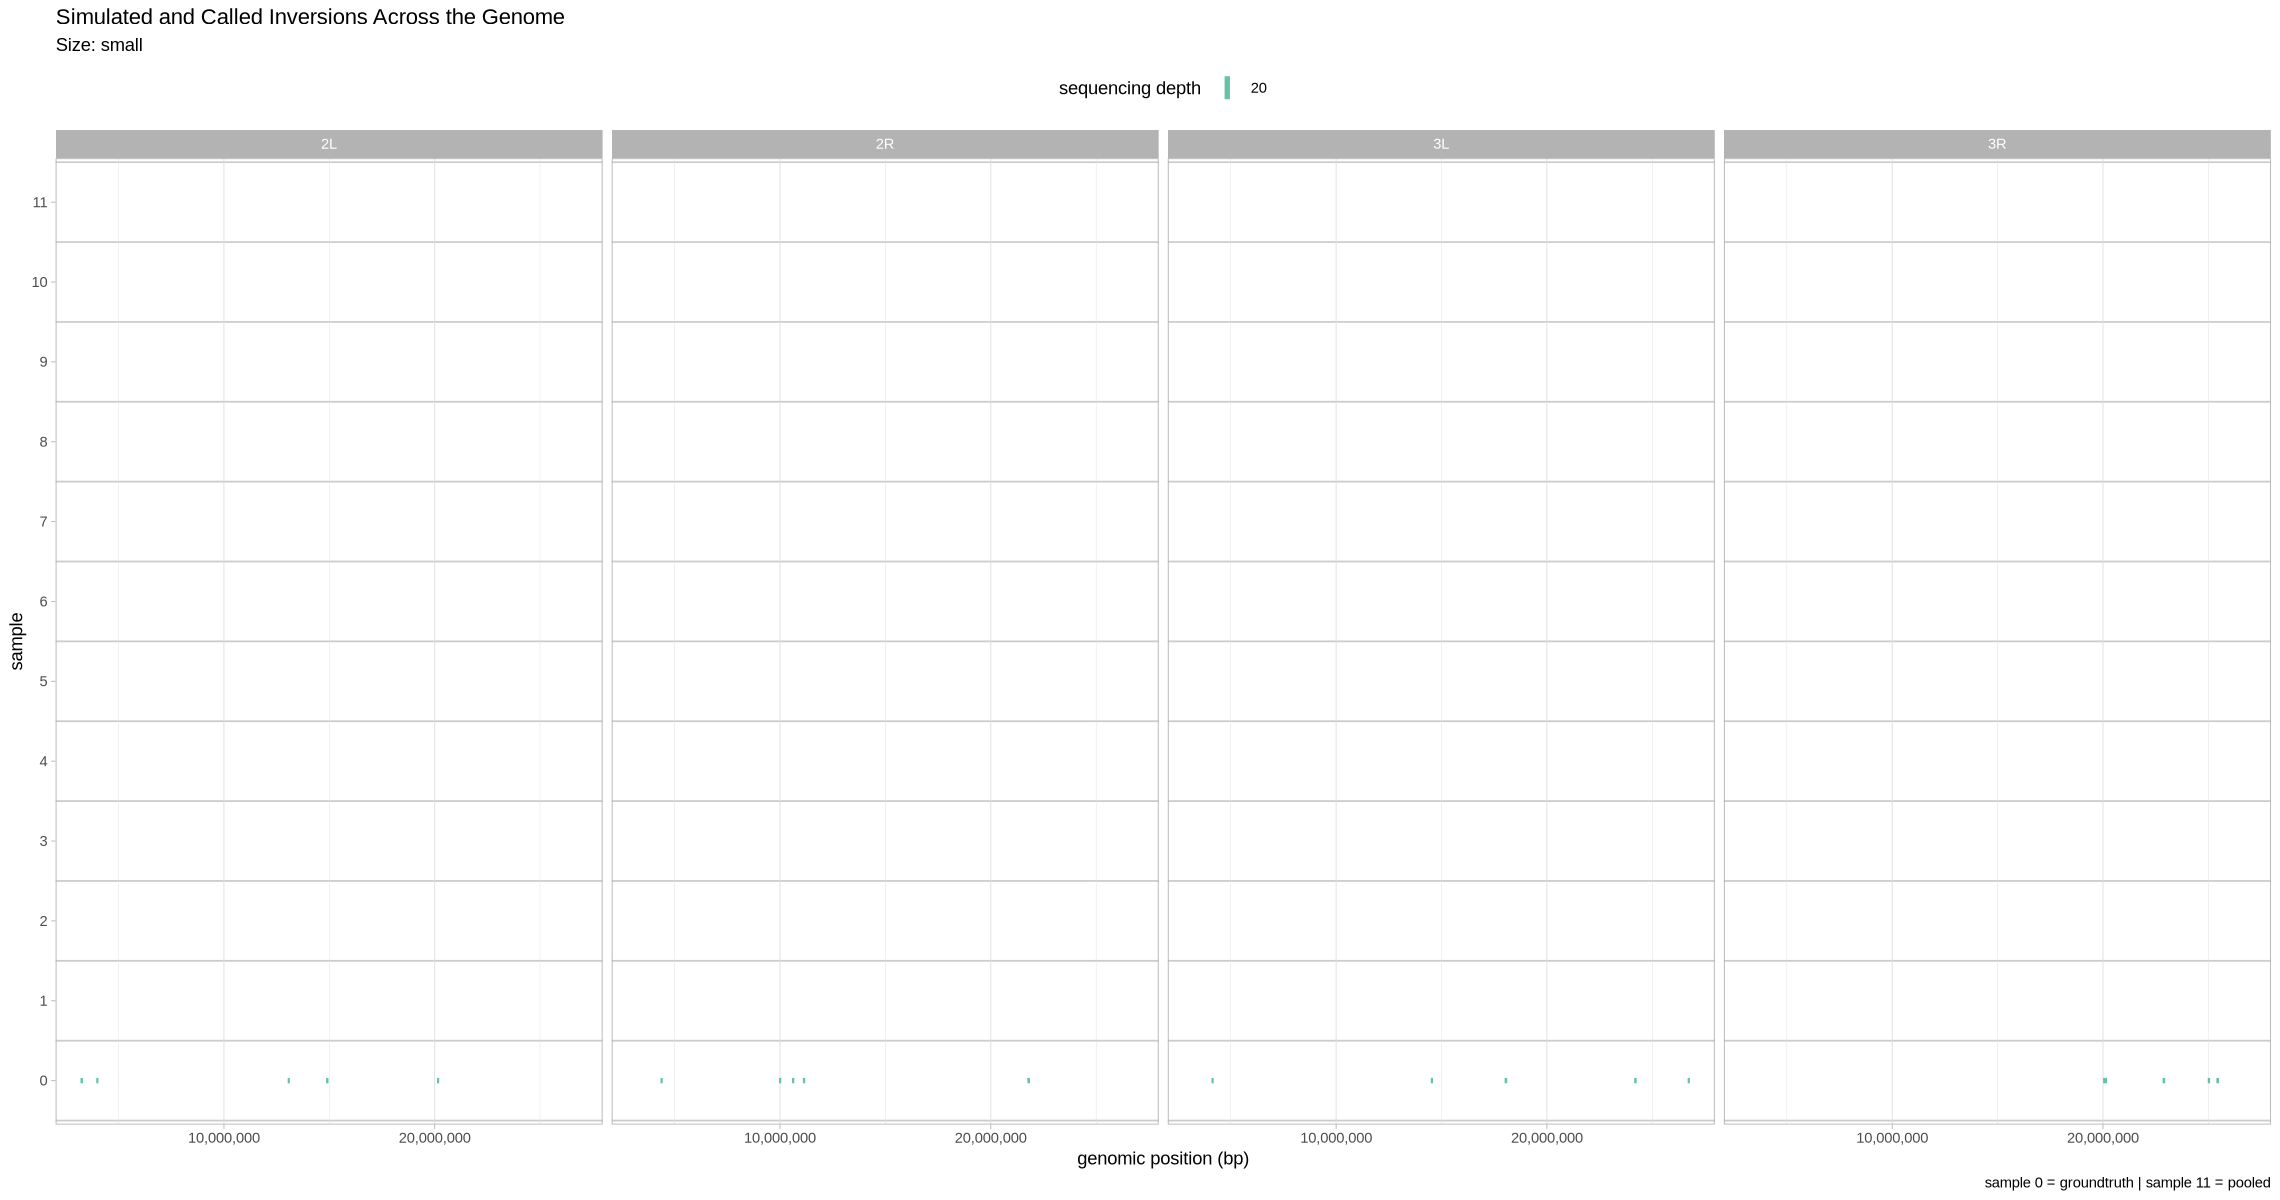

In [64]:
plot_inversions(performance, simulated_for_plot, .size)

What does this look like as a heatmap of true/false positive/negative?

In [57]:
plot_samples_matrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 10, repr.plot.height = 15)
    .data <- data[data$sample != 11,]
    axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
    ggplot(.data, aes(y = sample, x = id, fill = assessment, pattern = zygosity)) +
        geom_tile_pattern(
            pattern_color = NA,
            color = "white",
            pattern_fill = "black",
            pattern_angle = 45,
            pattern_density = 0.5,
            pattern_spacing = 0.025,
            pattern_key_scale_factor = 1
        ) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = paste(size_treatment, "inversions detected in individual samples, as a function of zygotic state.")) +
        scale_fill_manual(values = c("false negative" = "#eaf398ff", "true negative" = "grey70", "true positive" = "#90aed8")) +
        scale_pattern_manual(values = c("het" = "circle", "hom" = "none")) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        coord_cartesian(xlim = c(1, max(data$id)), expand = F) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(rows = vars(depth))
}

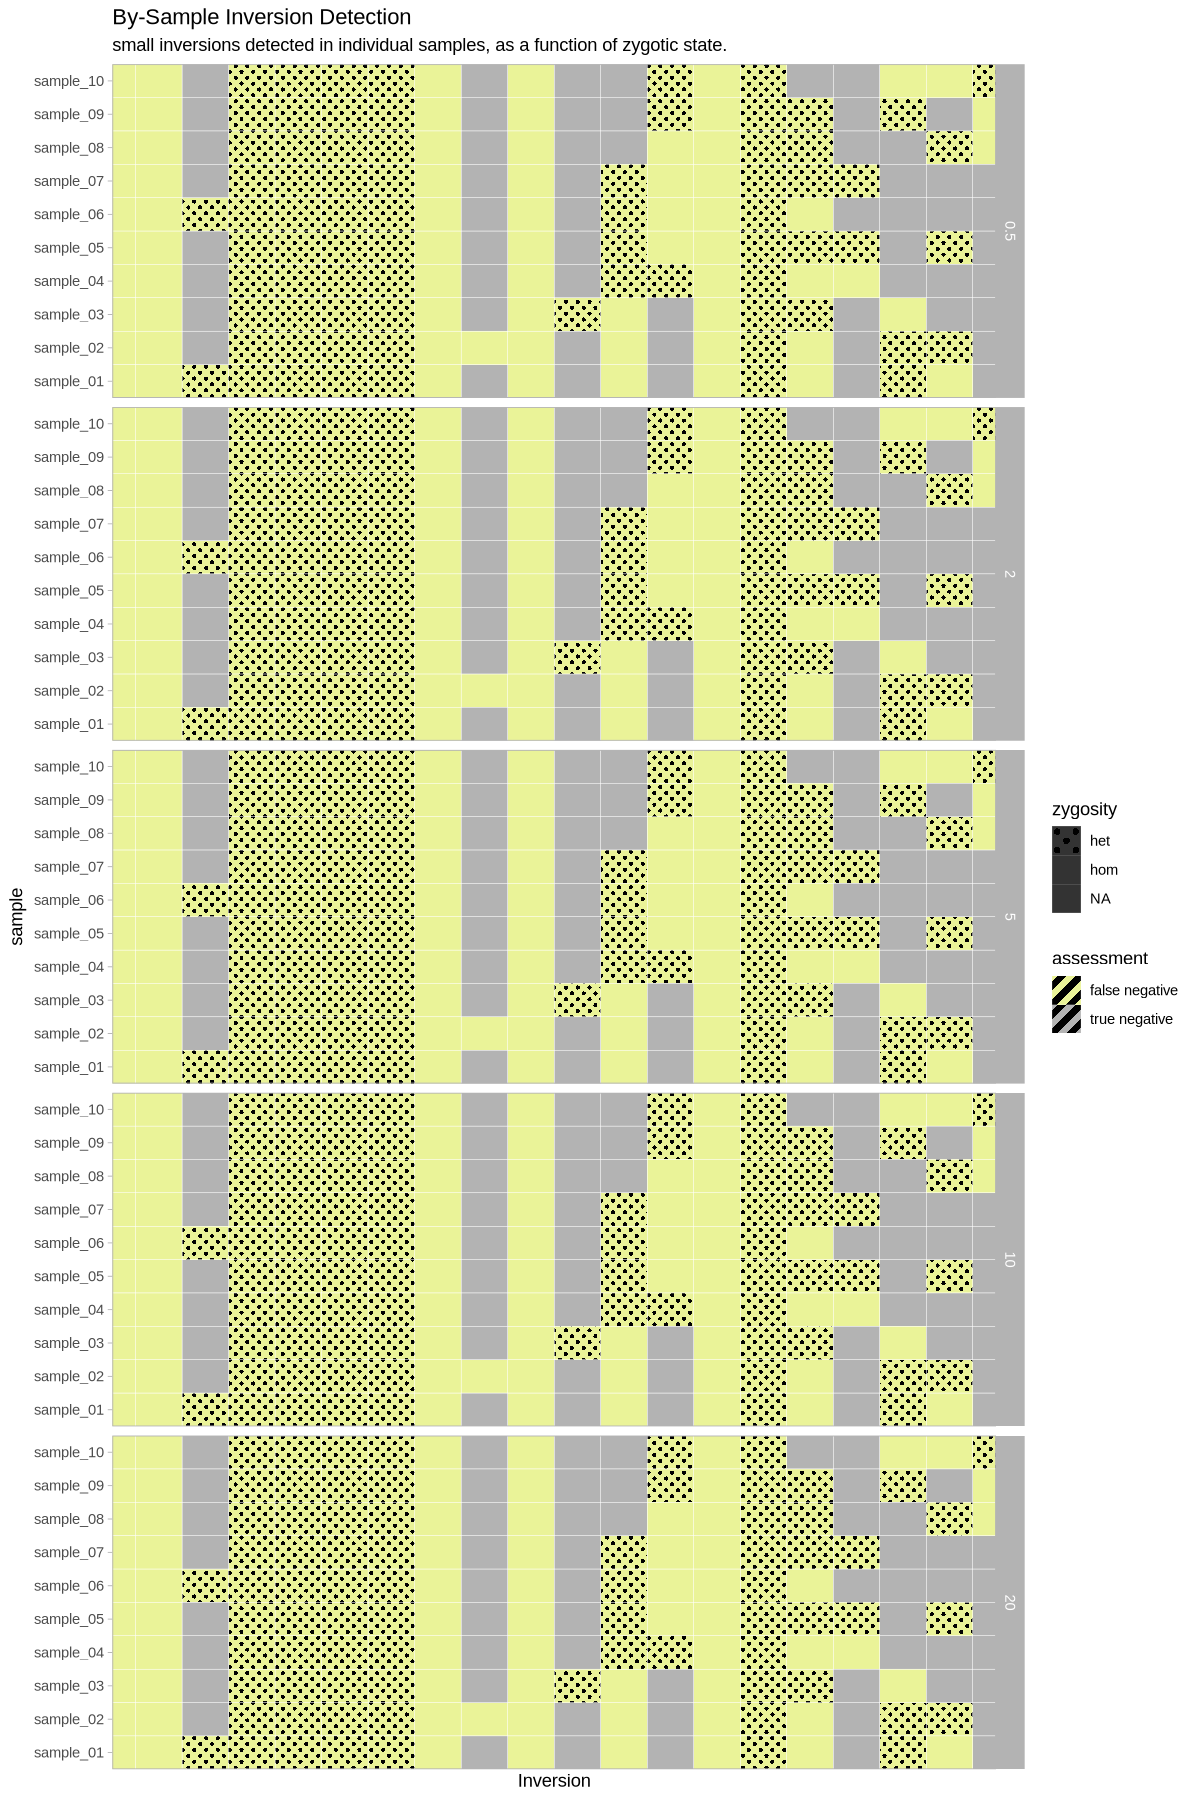

In [58]:
plot_samples_matrix(performance, .size)

### Pooled Sample Detection 

In [59]:
plot_pools_matrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 15, repr.plot.height = 10)
    .data <- data[data$sample == 11,]
    .data$contig <- gsub("2L", "2L (all homozygous)", .data$contig)
    .data$contig <- gsub("2R", "2R (all heterozygous)", .data$contig)
    .data$contig <- gsub("3L", "3L (inversions common)", .data$contig)
    .data$contig <- gsub("3R", "3R (inversions rare)", .data$contig)
 
    ggplot(.data, aes(y = 1, x = inversion, fill = assessment)) +
        geom_tile(color = "white", linewidth = 1.5) +
        theme_light() +
        labs(title = "Pooled-Sample Detection", subtitle = paste(size_treatment, "inversions detected in sample-pooled data, as a function of inversion frequency in the population.")) +
        scale_fill_manual(values = c("false negative" = "grey70", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "Assessment") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        ) +
        coord_cartesian(xlim = c(1, max(data$inversion)), expand = F) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

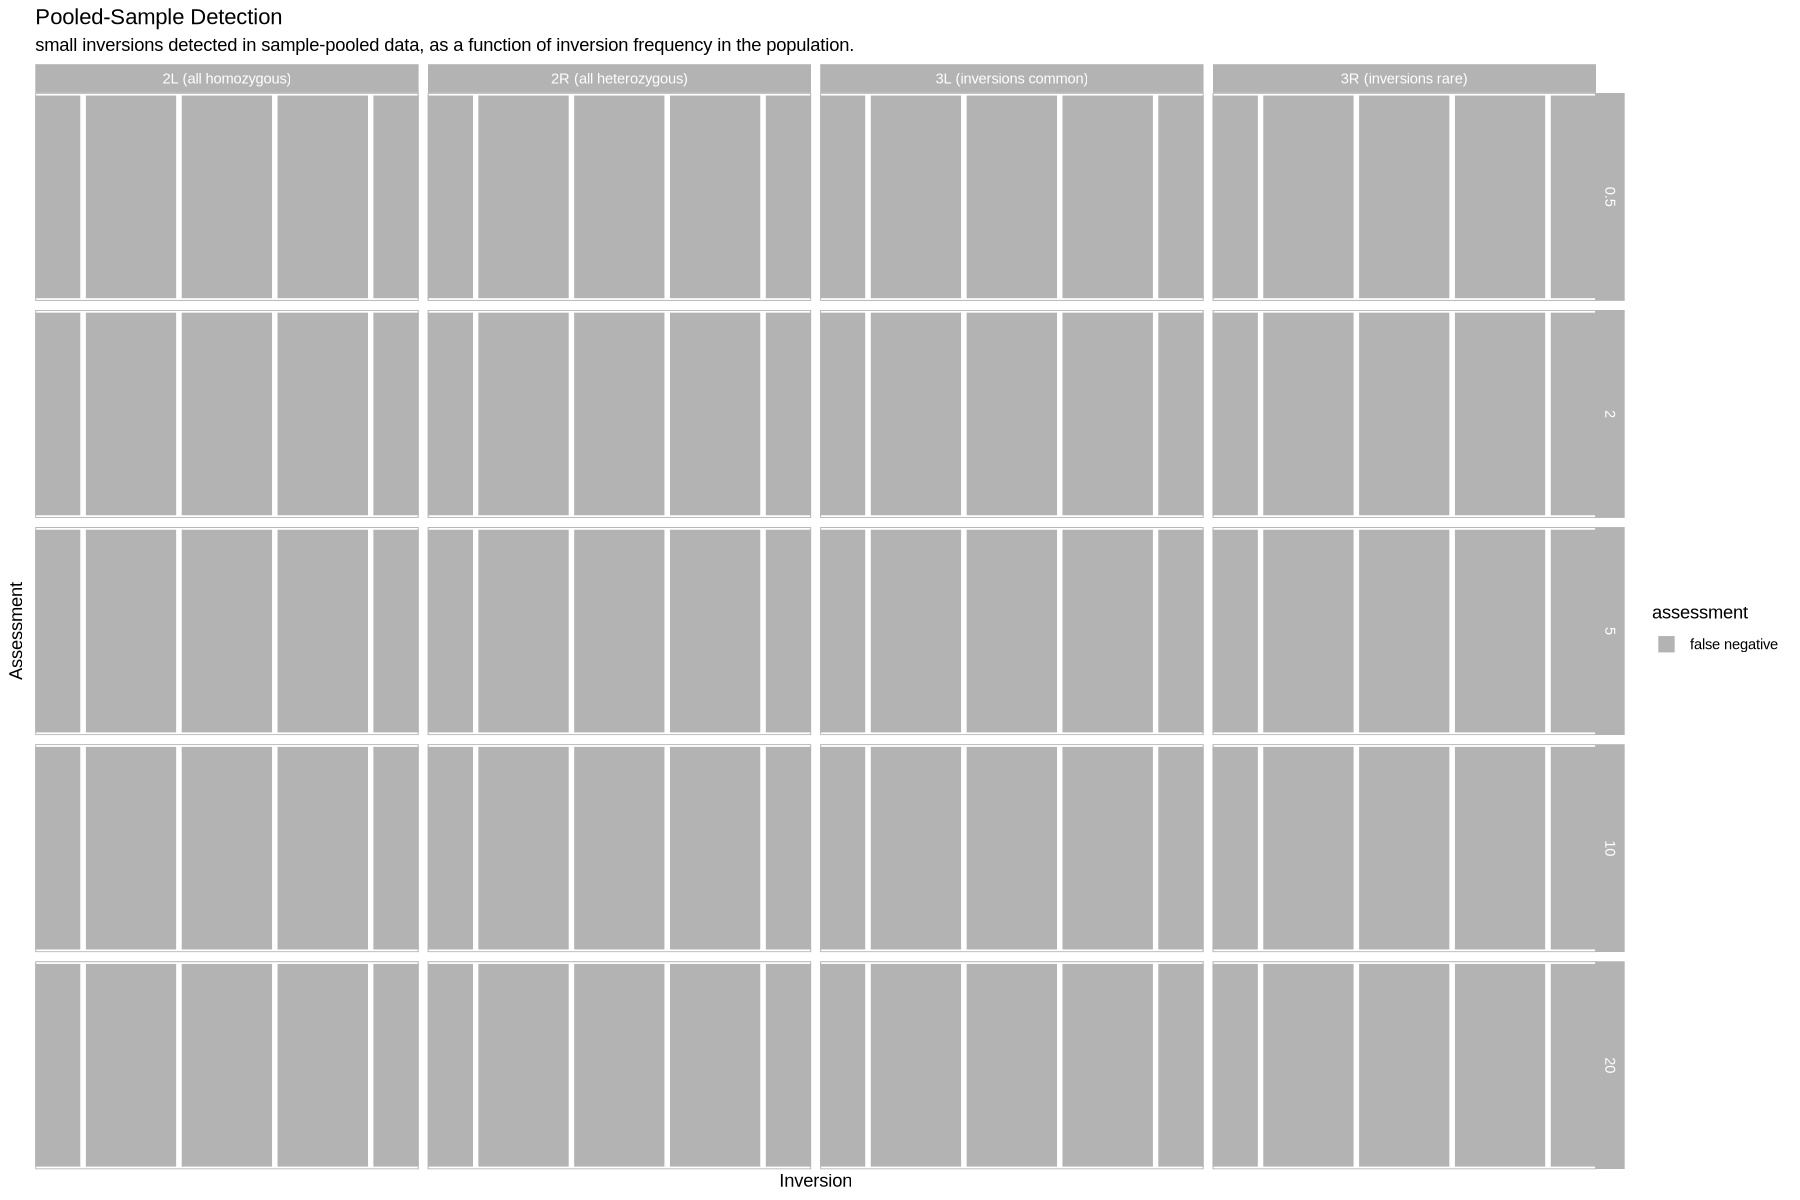

In [60]:
plot_pools_matrix(performance, .size)

Write this all to a file to tease apart later

In [61]:
write.csv(performance, file = paste0(.size, ".sv.naibr.assessment"), quote = F, row.names = F)

[1] TRUE